# Training Fresh vs Rotten Apple Classifiers

Two independent models are trained:

1. Otsu Features → Random Forest
2. GrabCut Features → Random Forest

The resulting models are exported for Streamlit deployment.

In [24]:
import os
import joblib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [25]:
def train_pipeline(
    X_path,
    y_path,
    model_name
):

    print("=" * 60)
    print(f"TRAINING: {model_name}")
    print("=" * 60)

    X = pd.read_csv(X_path)

    y = pd.read_csv(
        y_path
    ).squeeze()

    # ---------------------------------
    # Split
    # ---------------------------------

    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.25,
        random_state=42,
        stratify=y_temp
    )

    print("Train:", len(X_train))
    print("Val  :", len(X_val))
    print("Test :", len(X_test))

    # ---------------------------------
    # Scaling
    # ---------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_val_scaled = scaler.transform(
        X_val
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    # ---------------------------------
    # Model
    # ---------------------------------

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    # ---------------------------------
    # Validation
    # ---------------------------------

    y_val_pred = model.predict(
        X_val_scaled
    )

    val_acc = accuracy_score(
        y_val,
        y_val_pred
    )

    print()
    print(f"Validation Accuracy: {val_acc:.4f}")

    # ---------------------------------
    # Test
    # ---------------------------------

    y_pred = model.predict(
        X_test_scaled
    )

    print()
    print("TEST RESULTS")
    print()

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=model.classes_,
        yticklabels=model.classes_
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

    # ---------------------------------
    # Feature Importance
    # ---------------------------------

    importances = pd.Series(
        model.feature_importances_,
        index=X.columns
    )

    importances = importances.sort_values(
        ascending=False
    )

    plt.figure(figsize=(8,6))

    sns.barplot(
        x=importances.head(10).values,
        y=importances.head(10).index
    )

    plt.title(
        f"Top Features - {model_name}"
    )

    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "scaler": scaler,
        "columns": X.columns.tolist(),
        "accuracy": accuracy_score(
            y_test,
            y_pred
        )
    }

## Train Otsu Model

TRAINING: OTSU
Train: 480
Val  : 160
Test : 160

Validation Accuracy: 0.8938

TEST RESULTS

              precision    recall  f1-score   support

       fresh       0.99      0.82      0.90        80
      rotten       0.85      0.99      0.91        80

    accuracy                           0.91       160
   macro avg       0.92      0.91      0.91       160
weighted avg       0.92      0.91      0.91       160



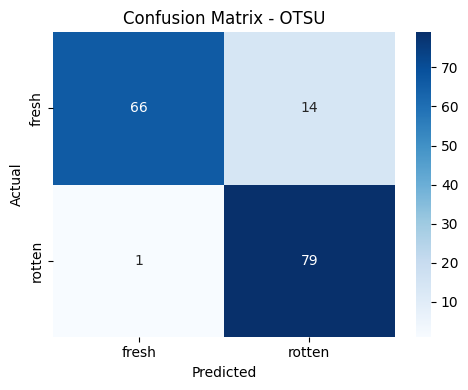

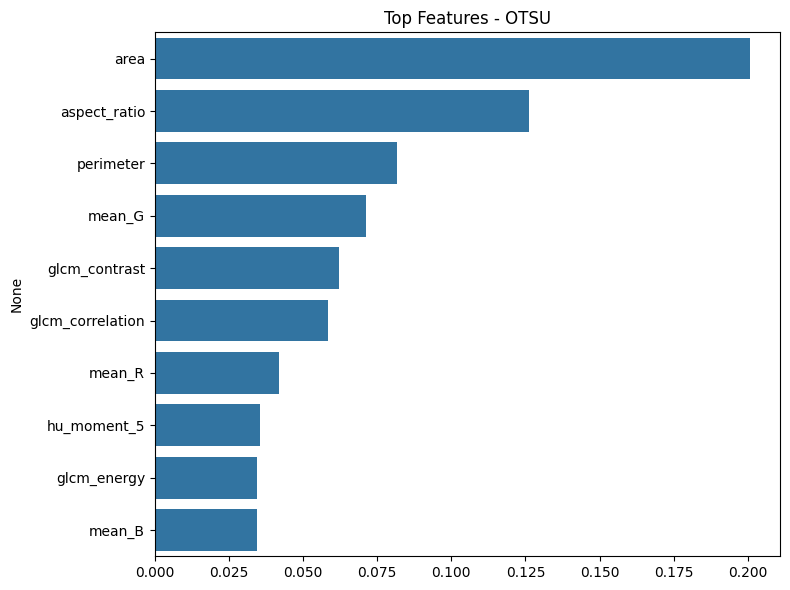

In [26]:
otsu_results = train_pipeline(
    "../outputs/X_otsu.csv",
    "../outputs/y_otsu.csv",
    "OTSU"
)

## Train GrabCut Model

TRAINING: GRABCUT
Train: 480
Val  : 160
Test : 160

Validation Accuracy: 0.9375

TEST RESULTS

              precision    recall  f1-score   support

       fresh       0.99      0.97      0.98        80
      rotten       0.98      0.99      0.98        80

    accuracy                           0.98       160
   macro avg       0.98      0.98      0.98       160
weighted avg       0.98      0.98      0.98       160



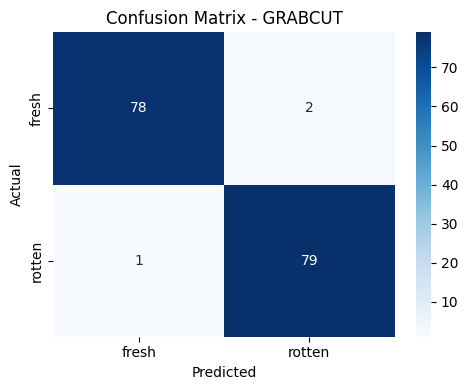

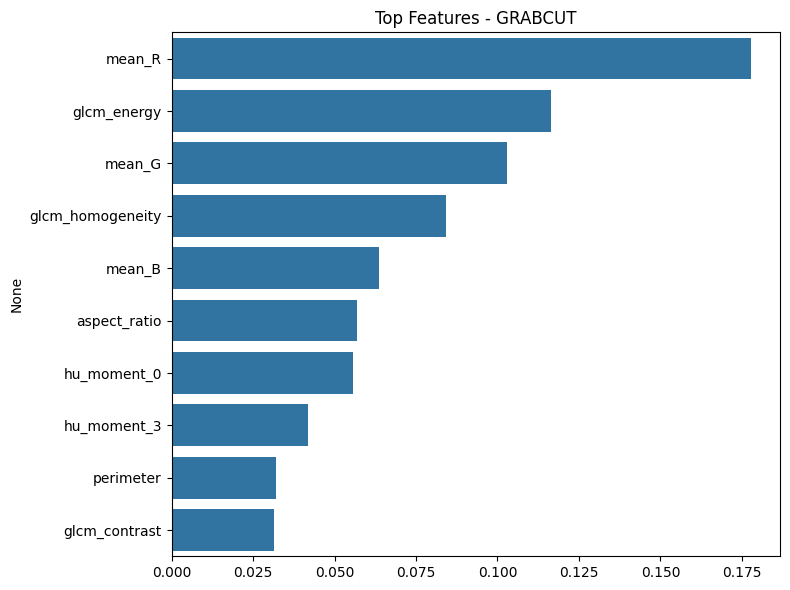

In [27]:
grabcut_results = train_pipeline(
    "../outputs/X_grabcut.csv",
    "../outputs/y_grabcut.csv",
    "GRABCUT"
)

## Compare Results

In [28]:
comparison = pd.DataFrame({

    "Model": [
        "Otsu",
        "GrabCut"
    ],

    "Accuracy": [
        otsu_results["accuracy"],
        grabcut_results["accuracy"]
    ]
})

comparison

,Model,Accuracy
0,Otsu,0.90625
1,GrabCut,0.98125


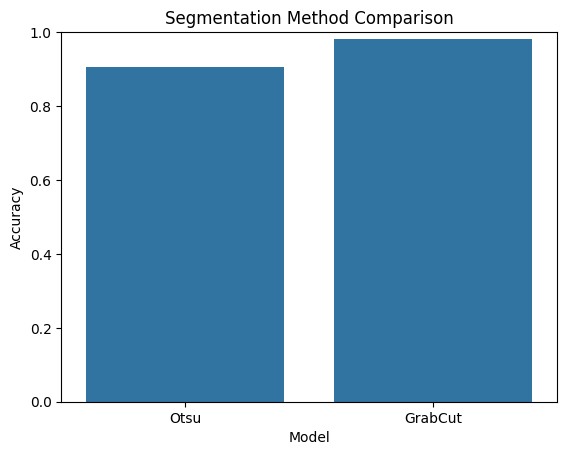

In [29]:
sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(
    0,
    1
)

plt.title(
    "Segmentation Method Comparison"
)

plt.show()

## Export Models For Streamlit

In [30]:
os.makedirs(
    "../outputs/models",
    exist_ok=True
)

# -------------------------
# OTSU
# -------------------------

joblib.dump(
    otsu_results["model"],
    "../outputs/models/rf_otsu.pkl"
)

joblib.dump(
    otsu_results["scaler"],
    "../outputs/models/scaler_otsu.pkl"
)

joblib.dump(
    otsu_results["columns"],
    "../outputs/models/features_otsu.pkl"
)

# -------------------------
# GRABCUT
# -------------------------

joblib.dump(
    grabcut_results["model"],
    "../outputs/models/rf_grabcut.pkl"
)

joblib.dump(
    grabcut_results["scaler"],
    "../outputs/models/scaler_grabcut.pkl"
)

joblib.dump(
    grabcut_results["columns"],
    "../outputs/models/features_grabcut.pkl"
)

print()
print("Models exported successfully.")


Models exported successfully.
